In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import scipy.io
import mne
import time
import os

In [ ]:

data = scipy.io.loadmat(DATA_PATH + 'S1901-P300_classic.mat')
X_real = data['epochs']
y_real = data['labels'].flatten()

print(f"Данные загружены: {X_real.shape}")
print(f"Target: {np.sum(y_real==1)}, Non-target: {np.sum(y_real==0)}")


Данные загружены: (6759, 3, 250)
Target: 415, Non-target: 6344


In [ ]:
def normalize_epochs_1(epochs):
    normalized = epochs.copy()
    for ch in range(epochs.shape[1]):
        mean = epochs[:, ch, :].mean()
        std = epochs[:, ch, :].std()
        if std > 0:
            normalized[:, ch, :] = (epochs[:, ch, :] - mean) / std
    return normalized

def concatenate_epochs_16(epochs, labels, seq_length=16):
    n_epochs = len(epochs)
    n_sequences = n_epochs // seq_length

    sequences = []
    targets = []

    for i in range(n_sequences):
        seq = epochs[i*seq_length:(i+1)*seq_length]
        seq_labels = labels[i*seq_length:(i+1)*seq_length]
        target_idx = np.where(seq_labels == 1)[0]

        if len(target_idx) == 1:
            sequences.append(seq)
            targets.append(target_idx[0])

    return np.array(sequences), np.array(targets)

def build_sequences_new(all_target, all_non_target, n_classes=16, n_samples=2000):
    X = []
    y = []

    targets = np.array(all_target._data)
    non_targets = np.array(all_non_target._data)

    for _ in range(n_samples):
        class_id = np.random.randint(n_classes)
        t = targets[np.random.randint(len(targets))]
        nts = non_targets[np.random.randint(len(non_targets), size=n_classes - 1)]

        seq = []
        nt_i = 0
        for pos in range(n_classes):
            if pos == class_id:
                seq.append(t)
            else:
                seq.append(nts[nt_i])
                nt_i += 1

        seq = np.stack(seq, axis=0)
        X.append(seq)
        y.append(class_id)

    return np.array(X), np.array(y)

def build_averaged_dataset(X, y, K=10, repeats=10):
    X_avg = []
    y_avg = []
    classes = np.unique(y)

    for cls in classes:
        Xc = X[y == cls]
        for _ in range(repeats):
            idx = np.random.choice(len(Xc), min(K, len(Xc)), replace=False)
            avg = Xc[idx].mean(axis=0)
            X_avg.append(avg)
            y_avg.append(cls)

    return np.stack(X_avg), np.array(y_avg)

def to_collapsed_format(sequences):
    return sequences.reshape(sequences.shape[0], 1, 3, 16 * 250)

In [ ]:
X_norm = normalize_epochs_1(X_real)

ch_names = ['Fz', 'Cz', 'Pz']
sfreq = 250
info = mne.create_info(ch_names, sfreq, ch_types='eeg')
events = np.column_stack((np.arange(len(y_real)), np.zeros(len(y_real), int), y_real))
event_id = {'non-target': 0, 'target': 1}

epochs_mne = mne.EpochsArray(X_norm, info, events=events, event_id=event_id)

#фильтрация (без filter_length)
epochs_mne.filter(l_freq=1, h_freq=15)

all_target = epochs_mne['target']
all_non_target = epochs_mne['non-target']

synth_sequences, synth_targets = build_sequences_new(
    all_target, all_non_target, n_classes=16, n_samples=2000
)

print(f"Синтетические данные: {synth_sequences.shape}")

Not setting metadata
6759 matching events found
No baseline correction applied
0 projection items activated
Setting up band-pass filter from 1 - 15 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 15.00 Hz
- Upper transition bandwidth: 3.75 Hz (-6 dB cutoff frequency: 16.88 Hz)
- Filter length: 825 samples (3.300 s)



/tmp/ipykernel_696/3360768707.py:12: RuntimeWarning: filter_length (825) is longer than the signal (250), distortion is likely. Reduce filter length or filter a longer signal.
  epochs_mne.filter(l_freq=1, h_freq=15)


Синтетические данные: (2000, 16, 3, 250)


In [ ]:
class SimpleTransformerCollapsed(nn.Module):
    def __init__(self, n_classes=16):
        super().__init__()

        self.spatial_conv = nn.Conv2d(1, 32, (3, 1), bias=False)
        self.bn1 = nn.BatchNorm2d(32)

        self.temporal_conv = nn.Conv2d(32, 32, (1, 8), stride=(1, 4), padding=(0, 2))
        self.bn2 = nn.BatchNorm2d(32)

        self.pool = nn.AdaptiveAvgPool2d((1, 250))

        self.pre_norm = nn.LayerNorm(32)
        self.pre_dropout = nn.Dropout(0.1)
        self.pre_linear = nn.Linear(32, 32)

        self.pos_encoder = nn.Parameter(torch.randn(1, 250, 32) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=32, nhead=4, dim_feedforward=128,
            dropout=0.1, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.classifier = nn.Linear(32, n_classes)

    def forward(self, x):
        x = self.spatial_conv(x)
        x = self.bn1(x)
        x = F.leaky_relu(x, 0.2)

        x = self.temporal_conv(x)
        x = self.bn2(x)
        x = F.leaky_relu(x, 0.2)

        x = self.pool(x)
        x = x.squeeze(2)
        x = x.permute(0, 2, 1)

        x = self.pre_norm(x)
        x = self.pre_dropout(x)
        x = self.pre_linear(x)
        x = F.gelu(x)
        x = x + self.pos_encoder[:, :x.size(1), :]

        x = self.transformer(x)
        x = x.mean(dim=1)
        return self.classifier(x)


In [ ]:

criterion = nn.CrossEntropyLoss()

def train_simple(X_train_t, y_train_t, X_val_t, y_val_t, n_epochs=100):
    model = SimpleTransformerCollapsed(n_classes=16).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    best_val_acc = 0

    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        output = model(X_train_t)
        loss = criterion(output, y_train_t)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 20 == 0:
            model.eval()
            with torch.no_grad():
                train_acc = (model(X_train_t).argmax(dim=1) == y_train_t).float().mean().item()
                val_acc = (model(X_val_t).argmax(dim=1) == y_val_t).float().mean().item()

                print(f"  Epoch {epoch+1:3d}: Train Acc = {train_acc*100:.1f}%, Val Acc = {val_acc*100:.1f}%")

                if val_acc > best_val_acc:
                    best_val_acc = val_acc

    return best_val_acc

def run_experiment(X_train, y_train, X_val, y_val, n_runs=2, n_epochs=100):
    results = []

    X_train_t = torch.FloatTensor(X_train).to(device)
    y_train_t = torch.LongTensor(y_train).to(device)
    X_val_t = torch.FloatTensor(X_val).to(device)
    y_val_t = torch.LongTensor(y_val).to(device)

    for run in range(n_runs):
        print(f"\n  Run {run+1}/{n_runs}")

        seed = 42 + run * 100
        torch.manual_seed(seed)
        np.random.seed(seed)

        best_acc = train_simple(X_train_t, y_train_t, X_val_t, y_val_t, n_epochs=n_epochs)
        results.append(best_acc * 100)
        print(f"    Результат: {best_acc*100:.1f}%")

    return results


In [ ]:
def prepare_data_for_K(K, repeats):
    print(f"подготовка данных для K={K}")

    if K == 1:
        X_data = synth_sequences
        y_data = synth_targets
        print(f"оригинальные данные - {len(X_data)} примеров")
    else:
        X_avg, y_avg = build_averaged_dataset(synth_sequences, synth_targets, K=K, repeats=repeats)
        X_data = X_avg
        y_data = y_avg
        print(f"создано {len(X_data)} усреднённых примеров")

    X_collapsed = to_collapsed_format(X_data)

    X_train, X_val, y_train, y_val = train_test_split(
        X_collapsed, y_data, test_size=0.2, random_state=42, stratify=y_data
    )

    print(f"    Train: {X_train.shape[0]}, Val: {X_val.shape[0]}")

    return X_train, y_train, X_val, y_val


In [ ]:

experiments = [
    {'K': 1, 'repeats': None, 'name': 'K=1 (без усреднения)', 'n_runs': 2},
    {'K': 3, 'repeats': 25, 'name': 'K=3 (усреднение по 3)', 'n_runs': 2},
    {'K': 5, 'repeats': 25, 'name': 'K=5 (усреднение по 5)', 'n_runs': 2},
    {'K': 10, 'repeats': 25, 'name': 'K=10 (усреднение по 10)', 'n_runs': 2},
]

all_results = []

for exp in experiments:
    print(f"{exp['name']}")

    try:
        X_train, y_train, X_val, y_val = prepare_data_for_K(exp['K'], exp['repeats'])

        results = run_experiment(X_train, y_train, X_val, y_val,
                                  n_runs=exp['n_runs'], n_epochs=100)

        all_results.append({
            'name': exp['name'],
            'K': exp['K'],
            'samples': len(X_train) + len(X_val),
            'mean_acc': np.mean(results),
            'std_acc': np.std(results),
            'results': results
        })

        print(f"результат: {np.mean(results):.1f}% ± {np.std(results):.1f}%")

    except Exception as e:
        print(f"ошибка {e}")
        all_results.append({
            'name': exp['name'],
            'K': exp['K'],
            'samples': 0,
            'mean_acc': 0,
            'std_acc': 0,
            'results': []
        })


K=1 (без усреднения)
подготовка данных для K=1
оригинальные данные - 2000 примеров
    Train: 1600, Val: 400

  Run 1/2
  Epoch  20: Train Acc = 8.1%, Val Acc = 7.8%
  Epoch  40: Train Acc = 9.1%, Val Acc = 8.7%
  Epoch  60: Train Acc = 10.2%, Val Acc = 8.2%
  Epoch  80: Train Acc = 12.9%, Val Acc = 8.2%
  Epoch 100: Train Acc = 13.0%, Val Acc = 6.2%
    Результат: 8.7%

  Run 2/2
  Epoch  20: Train Acc = 8.7%, Val Acc = 9.7%
  Epoch  40: Train Acc = 9.3%, Val Acc = 9.3%
  Epoch  60: Train Acc = 10.9%, Val Acc = 8.0%
  Epoch  80: Train Acc = 12.4%, Val Acc = 9.5%
  Epoch 100: Train Acc = 18.8%, Val Acc = 11.7%
    Результат: 11.7%
результат: 10.2% ± 1.5%
K=3 (усреднение по 3)
подготовка данных для K=3
создано 400 усреднённых примеров
    Train: 320, Val: 80

  Run 1/2
  Epoch  20: Train Acc = 15.0%, Val Acc = 13.8%
  Epoch  40: Train Acc = 18.8%, Val Acc = 12.5%
  Epoch  60: Train Acc = 19.7%, Val Acc = 16.3%
  Epoch  80: Train Acc = 32.5%, Val Acc = 10.0%
  Epoch 100: Train Acc = 36.6

In [ ]:

print(f"{'Эксперимент':<25} {'K':<3} {'Примеров':<8} {'Точность':<15}")

for r in all_results:
    if r['mean_acc'] > 0:
        print(f"{r['name']:<25} {r['K']:<3} {r['samples']:<8} {r['mean_acc']:.1f}% ± {r['std_acc']:.1f}%")
    else:
        print(f"{r['name']:<25} {r['K']:<3} {r['samples']:<8} Ошибка")



Эксперимент               K   Примеров Точность       
K=1 (без усреднения)      1   2000     10.2% ± 1.5%
K=3 (усреднение по 3)     3   400      14.4% ± 1.9%
K=5 (усреднение по 5)     5   400      28.1% ± 6.9%
K=10 (усреднение по 10)   10  400      27.5% ± 5.0%


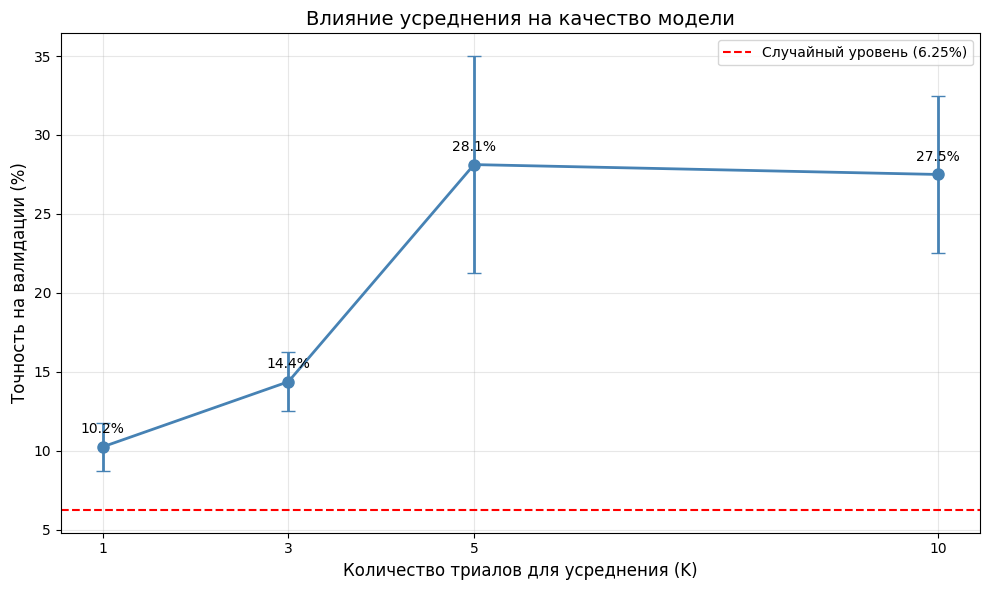

In [ ]:
plt.figure(figsize=(10, 6))

K_values = [r['K'] for r in valid_results]
means = [r['mean_acc'] for r in valid_results]
stds = [r['std_acc'] for r in valid_results]

plt.errorbar(K_values, means, yerr=stds, fmt='o-', capsize=5,
             color='steelblue', linewidth=2, markersize=8)

plt.axhline(y=6.25, color='red', linestyle='--', label='Случайный уровень (6.25%)')

plt.xlabel('Количество триалов для усреднения (K)', fontsize=12)
plt.ylabel('Точность на валидации (%)', fontsize=12)
plt.title('Влияние усреднения на качество модели', fontsize=14)
plt.xticks(K_values)
plt.legend()
plt.grid(True, alpha=0.3)

for k, mean, std in zip(K_values, means, stds):
    plt.annotate(f'{mean:.1f}%', (k, mean), textcoords="offset points", xytext=(0, 10), ha='center')

plt.tight_layout()
plt.savefig('trend_with_ci.png', dpi=150)
plt.show()

learning curve для K=10

In [ ]:

X_avg, y_avg = build_averaged_dataset(synth_sequences, synth_targets, K=10, repeats=25)
X_collapsed = to_collapsed_format(X_avg)

X_train, X_val, y_train, y_val = train_test_split(
    X_collapsed, y_avg, test_size=0.2, random_state=42, stratify=y_avg
)

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}")

X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.LongTensor(y_train).to(device)
X_val_t = torch.FloatTensor(X_val).to(device)
y_val_t = torch.LongTensor(y_val).to(device)

model = SimpleTransformerCollapsed(n_classes=16).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train_accs = []
val_accs = []
epochs_list = []

best_val_acc = 0

for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    output = model(X_train_t)
    loss = criterion(output, y_train_t)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        model.eval()
        with torch.no_grad():
            train_acc = (model(X_train_t).argmax(dim=1) == y_train_t).float().mean().item()
            val_acc = (model(X_val_t).argmax(dim=1) == y_val_t).float().mean().item()

            epochs_list.append(epoch + 1)
            train_accs.append(train_acc * 100)
            val_accs.append(val_acc * 100)

            print(f"Epoch {epoch+1:3d}: Train Acc = {train_acc*100:.1f}%, Val Acc = {val_acc*100:.1f}%")

            if val_acc > best_val_acc:
                best_val_acc = val_acc

print(f"Лучшая точность: {best_val_acc*100:.1f}%")


Train: 320, Val: 80
Epoch  10: Train Acc = 7.5%, Val Acc = 7.5%
Epoch  20: Train Acc = 9.4%, Val Acc = 10.0%
Epoch  30: Train Acc = 15.9%, Val Acc = 12.5%
Epoch  40: Train Acc = 24.1%, Val Acc = 21.3%
Epoch  50: Train Acc = 27.2%, Val Acc = 13.8%
Epoch  60: Train Acc = 29.1%, Val Acc = 15.0%
Epoch  70: Train Acc = 33.4%, Val Acc = 15.0%
Epoch  80: Train Acc = 37.5%, Val Acc = 15.0%
Epoch  90: Train Acc = 32.8%, Val Acc = 17.5%
Epoch 100: Train Acc = 53.1%, Val Acc = 31.2%
Лучшая точность: 31.2%


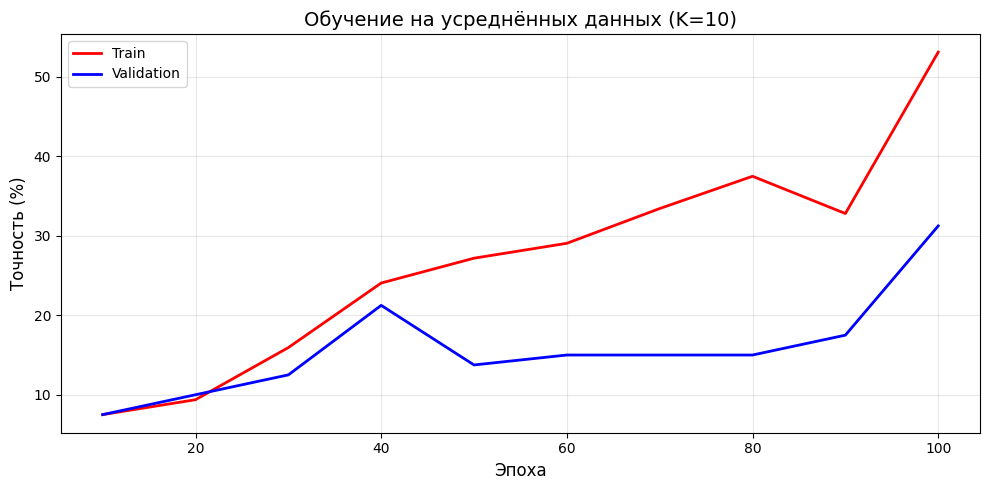

In [ ]:

plt.figure(figsize=(10, 5))
plt.plot(epochs_list, train_accs, 'r-', label='Train', linewidth=2)
plt.plot(epochs_list, val_accs, 'b-', label='Validation', linewidth=2)
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('Точность (%)', fontsize=12)
plt.title('Обучение на усреднённых данных (K=10)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('k10_learning_curve.png', dpi=150)
plt.show()